# 🔗 Notebook 03: Bayesian VAR for Marketers — Modeling Long-Term Cross-Channel Effects

**Marketing channels don't work in isolation.** TV drives brand search. Social media sparks direct website visits. A spike in PR coverage lifts all paid channels. These indirect, lagged pathways are invisible to standard MMM — but a **Vector AutoRegression (VAR)** model captures them.

This notebook teaches you how to build a **Bayesian VAR** from scratch using PyMC, with **Minnesota prior shrinkage** that keeps the model sensible even with limited data. This is a key differentiator — PyMC-Marketing does not include a VAR module, so Simba's implementation fills a critical gap.

### What you'll learn:

1. **Why VAR matters** — MMM captures direct effects, VAR captures indirect/lagged cross-channel pathways
2. **The Minnesota prior** — how shrinkage regularizes a high-dimensional time series model
3. **Impulse Response Functions (IRF)** — "If I shock TV spend, what happens to Search and Revenue over the next 12 weeks?"
4. **Forecast Error Variance Decomposition (FEVD)** — "What fraction of Revenue variance is explained by each channel?"
5. **Long-run multipliers** — the total cumulative effect of each variable on every other

---

> **Note on execution:** This notebook uses **simulated posterior samples** rather than running actual MCMC sampling (which would take several minutes). The concepts and code structure are identical to what you'd use in production — we just skip the sampling step and work with synthetic draws instead.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC', 'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE', 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.color': '#D0D7DE', 'legend.framealpha': 0.9, 'legend.edgecolor': '#D0D7DE',
})
COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

np.random.seed(42)

# Load the sample dataset
df = pd.read_csv('data/sample_mmm_weekly.csv', parse_dates=['date'])
print(f'✅ Loaded {len(df)} rows of weekly marketing data')
print(f'   Columns: {list(df.columns)}')

✅ Loaded 104 rows of weekly marketing data
   Columns: ['date', 'revenue', 'tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend', 'competitor_spend', 'temperature', 'black_friday', 'christmas']


---

## Part 1: Why VAR Matters for Marketing

Standard **Media Mix Models (MMM)** estimate the direct effect of each channel on revenue:

$$\text{Revenue}_t = \beta_1 \cdot \text{TV}_t + \beta_2 \cdot \text{Search}_t + \beta_3 \cdot \text{Social}_t + \ldots$$

But what about **indirect pathways**? In reality:

- **TV ads** drive people to search for your brand online → **Search volume rises**
- **Social media** campaigns create buzz → **Direct traffic increases**  
- **Brand awareness** (from all channels) → **Conversions improve** weeks later

A VAR model captures these **cross-channel, lagged effects** by modeling every variable as a function of its own past **and** the past of every other variable.

Let's visualize these hidden pathways:

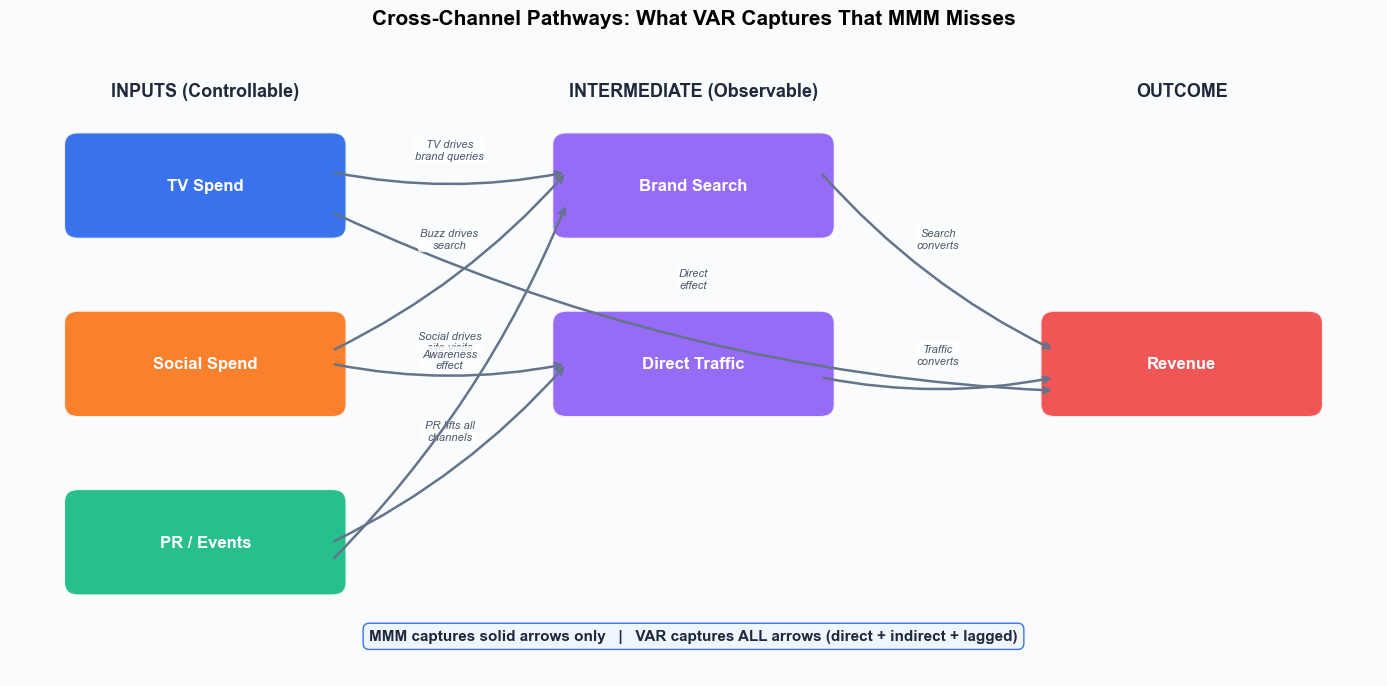

The diagram above shows why MMM alone is incomplete.
TV doesn't just drive Revenue directly — it also lifts Brand Search, which then converts to Revenue.
VAR captures these indirect, lagged pathways that MMM misses.


In [2]:
# --- Flow diagram: Cross-channel pathways ---
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#FAFBFC')
fig.patch.set_facecolor('#FAFBFC')

# Node positions
nodes = {
    'TV Spend':       (2, 5.5, COLORS[0]),
    'Social Spend':   (2, 3.5, COLORS[1]),
    'PR / Events':    (2, 1.5, COLORS[2]),
    'Brand Search':   (7, 5.5, COLORS[4]),
    'Direct Traffic':  (7, 3.5, COLORS[4]),
    'Revenue':        (12, 3.5, COLORS[3]),
}

# Draw nodes
for label, (x, y, color) in nodes.items():
    box = FancyBboxPatch((x - 1.3, y - 0.45), 2.6, 0.9,
                         boxstyle='round,pad=0.15', facecolor=color,
                         edgecolor='white', linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')

# Draw arrows (indirect pathways)
arrows = [
    ('TV Spend', 'Brand Search', 'TV drives\nbrand queries', 0.15),
    ('TV Spend', 'Revenue', 'Direct\neffect', -0.3),
    ('Social Spend', 'Direct Traffic', 'Social drives\nsite visits', 0.0),
    ('Social Spend', 'Brand Search', 'Buzz drives\nsearch', 0.15),
    ('PR / Events', 'Direct Traffic', 'PR lifts all\nchannels', 0.0),
    ('PR / Events', 'Brand Search', 'Awareness\neffect', -0.2),
    ('Brand Search', 'Revenue', 'Search\nconverts', 0.15),
    ('Direct Traffic', 'Revenue', 'Traffic\nconverts', -0.15),
]

for src, dst, label, offset in arrows:
    sx, sy, _ = nodes[src]
    dx, dy, _ = nodes[dst]
    ax.annotate('', xy=(dx - 1.3, dy + offset), xytext=(sx + 1.3, sy + offset),
                arrowprops=dict(arrowstyle='->', color='#64748B', lw=1.8,
                               connectionstyle='arc3,rad=0.1'))
    mid_x = (sx + dx) / 2
    mid_y = (sy + dy) / 2 + offset + 0.25
    ax.text(mid_x, mid_y, label, ha='center', va='center', fontsize=8,
            color='#475569', style='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Labels
ax.text(2, 6.5, 'INPUTS (Controllable)', ha='center', fontsize=13,
        fontweight='bold', color='#1E293B')
ax.text(7, 6.5, 'INTERMEDIATE (Observable)', ha='center', fontsize=13,
        fontweight='bold', color='#1E293B')
ax.text(12, 6.5, 'OUTCOME', ha='center', fontsize=13,
        fontweight='bold', color='#1E293B')

# MMM vs VAR annotation
ax.text(7, 0.4, 'MMM captures solid arrows only   |   VAR captures ALL arrows (direct + indirect + lagged)',
        ha='center', fontsize=11, fontweight='bold', color='#1E293B',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EFF6FF', edgecolor='#2563EB', alpha=0.9))

plt.title('Cross-Channel Pathways: What VAR Captures That MMM Misses', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('images/03_var_cross_channel_diagram.png', dpi=180, bbox_inches='tight')
plt.show()
print('The diagram above shows why MMM alone is incomplete.')
print('TV doesn\'t just drive Revenue directly — it also lifts Brand Search, which then converts to Revenue.')
print('VAR captures these indirect, lagged pathways that MMM misses.')

---

## Part 2: What Is a VAR Model?

A **Vector AutoRegression** models every variable as a linear function of lagged values of **all** variables in the system.

For a 3-variable system (TV, Search, Revenue) with 2 lags:

$$\begin{bmatrix} \text{TV}_t \\ \text{Search}_t \\ \text{Revenue}_t \end{bmatrix} = \mathbf{c} + \mathbf{A}_1 \begin{bmatrix} \text{TV}_{t-1} \\ \text{Search}_{t-1} \\ \text{Revenue}_{t-1} \end{bmatrix} + \mathbf{A}_2 \begin{bmatrix} \text{TV}_{t-2} \\ \text{Search}_{t-2} \\ \text{Revenue}_{t-2} \end{bmatrix} + \boldsymbol{\epsilon}_t$$

Where:
- **$\mathbf{A}_1, \mathbf{A}_2$** are $3 \times 3$ coefficient matrices (one per lag)
- **$\mathbf{c}$** is the intercept vector
- **$\boldsymbol{\epsilon}_t$** is the error vector with covariance matrix $\boldsymbol{\Sigma}$

The **diagonal** entries of $\mathbf{A}_1$ tell us how each variable depends on its **own** past (own-lag). The **off-diagonal** entries capture **cross-channel effects** (e.g., how last week's TV affects this week's Search).

### The problem: too many parameters

A 3-variable VAR(2) has $3 \times 3 \times 2 = 18$ coefficients plus 3 intercepts = **21 parameters**. With 5 variables and 4 lags, that's $5 \times 5 \times 4 + 5 = 105$ parameters! With only 104 weekly observations, we'd massively overfit.

This is where the **Minnesota prior** saves us.

---

## Part 3: The Minnesota Prior — Smart Shrinkage for VAR

The **Minnesota prior** (originally from the Federal Reserve Bank of Minneapolis) is the standard Bayesian prior for VAR models. The key ideas:

1. **Own-lag coefficients** are biased toward **0.9** (each variable is persistent — last week's Revenue predicts this week's Revenue)
2. **Cross-lag coefficients** are biased toward **0.0** (by default, other variables don't affect you — let the data prove otherwise)
3. **Higher lags get tighter priors** (recent past matters more than distant past)
4. **Shrinkage strength** is controlled by $\lambda$ (default 0.2 in Simba)

Let's visualize what the Minnesota prior looks like:

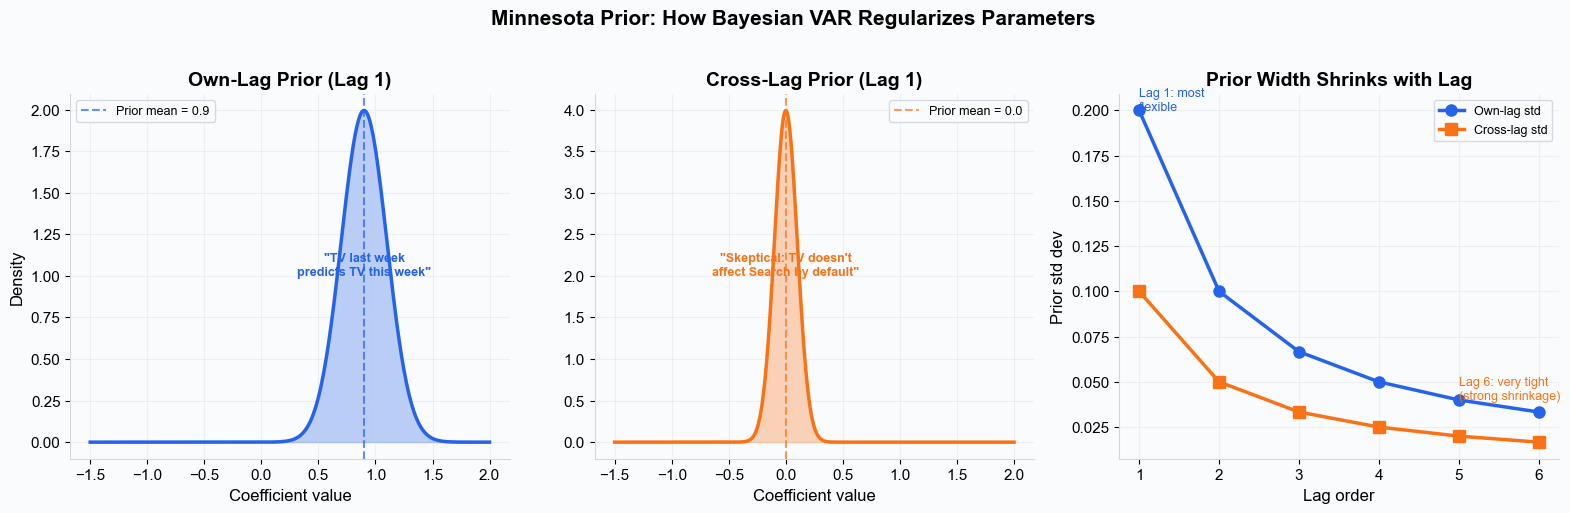

Key insight: The Minnesota prior encodes two beliefs:
  1. Each variable is persistent (own-lag ≈ 0.9)
  2. Cross-channel effects are small unless the data strongly disagrees (cross-lag ≈ 0.0)
  Shrinkage strength λ = 0.2 (Simba default)


In [3]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x = np.linspace(-1.5, 2.0, 500)

# Panel 1: Own-lag prior (centered at 0.9)
ax = axes[0]
lambda_shrink = 0.2
own_lag_mean = 0.9
own_lag_std = lambda_shrink  # lag 1
y = stats.norm.pdf(x, own_lag_mean, own_lag_std)
ax.fill_between(x, y, alpha=0.3, color=COLORS[0])
ax.plot(x, y, color=COLORS[0], linewidth=2.5)
ax.axvline(x=0.9, color=COLORS[0], linestyle='--', alpha=0.7, label='Prior mean = 0.9')
ax.set_title('Own-Lag Prior (Lag 1)')
ax.set_xlabel('Coefficient value')
ax.set_ylabel('Density')
ax.annotate('"TV last week\npredicts TV this week"', xy=(0.9, 1.0), fontsize=9,
           ha='center', color=COLORS[0], fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: Cross-lag prior (centered at 0.0)
ax = axes[1]
cross_lag_std = lambda_shrink * 0.5  # cross-lag is tighter
y_cross = stats.norm.pdf(x, 0.0, cross_lag_std)
ax.fill_between(x, y_cross, alpha=0.3, color=COLORS[1])
ax.plot(x, y_cross, color=COLORS[1], linewidth=2.5)
ax.axvline(x=0.0, color=COLORS[1], linestyle='--', alpha=0.7, label='Prior mean = 0.0')
ax.set_title('Cross-Lag Prior (Lag 1)')
ax.set_xlabel('Coefficient value')
ax.annotate('"Skeptical: TV doesn\'t\naffect Search by default"', xy=(0.0, 2.0), fontsize=9,
           ha='center', color=COLORS[1], fontweight='bold')
ax.legend(fontsize=9)

# Panel 3: Shrinkage by lag order
ax = axes[2]
lags = np.arange(1, 7)
own_stds = [lambda_shrink / l for l in lags]
cross_stds = [lambda_shrink * 0.5 / l for l in lags]
ax.plot(lags, own_stds, 'o-', color=COLORS[0], linewidth=2.5, markersize=8, label='Own-lag std')
ax.plot(lags, cross_stds, 's-', color=COLORS[1], linewidth=2.5, markersize=8, label='Cross-lag std')
ax.set_title('Prior Width Shrinks with Lag')
ax.set_xlabel('Lag order')
ax.set_ylabel('Prior std dev')
ax.annotate('Lag 1: most\nflexible', xy=(1, 0.2), fontsize=9, color=COLORS[0])
ax.annotate('Lag 6: very tight\n(strong shrinkage)', xy=(5, 0.04), fontsize=9, color=COLORS[1])
ax.legend(fontsize=9)

plt.suptitle('Minnesota Prior: How Bayesian VAR Regularizes Parameters', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/03_minnesota_prior.png', dpi=180, bbox_inches='tight')
plt.show()

print('Key insight: The Minnesota prior encodes two beliefs:')
print('  1. Each variable is persistent (own-lag ≈ 0.9)')
print('  2. Cross-channel effects are small unless the data strongly disagrees (cross-lag ≈ 0.0)')
print(f'  Shrinkage strength λ = {lambda_shrink} (Simba default)')

---

## Part 4: Generating Synthetic VAR Data

Before building the model, let's generate synthetic 3-variable VAR(2) data with **known coefficients** so we can verify our analysis recovers the truth.

Our three variables:
- **TV Spend** ($y_1$) — an input we control
- **Search Volume** ($y_2$) — partially driven by TV (the cross-channel effect we want to detect)
- **Revenue** ($y_3$) — driven by both TV and Search

We'll embed specific causal relationships:
- TV at lag 1 drives Search (coefficient 0.3) — TV ads cause people to search
- Search at lag 1 drives Revenue (coefficient 0.25) — search queries convert to sales
- TV at lag 1 has a small direct effect on Revenue (coefficient 0.15)

In [4]:
# --- Generate synthetic VAR(2) data ---

n_vars = 3
n_obs = 150  # 150 weeks (~3 years)
var_names = ['TV Spend', 'Search Volume', 'Revenue']

# True coefficient matrices
# A1[i,j] = effect of variable j at lag 1 on variable i at time t
A1_true = np.array([
    [0.70,  0.00,  0.00],   # TV: persistent, no feedback from others
    [0.30,  0.50,  0.05],   # Search: driven by TV (0.3), own persistence, small revenue feedback
    [0.15,  0.25,  0.60],   # Revenue: direct TV effect (0.15), search converts (0.25), persistent
])

A2_true = np.array([
    [0.10,  0.00,  0.00],   # TV: small lag-2 own effect
    [0.10,  0.15,  0.00],   # Search: TV still has lag-2 effect on search
    [0.05,  0.10,  0.10],   # Revenue: smaller lag-2 effects
])

# Intercepts (set to create realistic levels)
c_true = np.array([20.0, 10.0, 50.0])

# Innovation covariance (LKJ Cholesky in the real model)
sigma_true = np.array([
    [4.0, 1.0, 0.5],
    [1.0, 3.0, 0.8],
    [0.5, 0.8, 5.0],
])

# Generate data
Y = np.zeros((n_obs, n_vars))
Y[0] = c_true + np.random.multivariate_normal(np.zeros(n_vars), sigma_true)
Y[1] = c_true + np.random.multivariate_normal(np.zeros(n_vars), sigma_true)

for t in range(2, n_obs):
    Y[t] = c_true + A1_true @ Y[t-1] + A2_true @ Y[t-2] + \
           np.random.multivariate_normal(np.zeros(n_vars), sigma_true)

# Create DataFrame
dates = pd.date_range('2021-01-04', periods=n_obs, freq='W-MON')
df_var = pd.DataFrame(Y, columns=var_names, index=dates)
df_var.index.name = 'date'

print('True Coefficient Matrix A1 (lag 1):')
print(pd.DataFrame(A1_true, index=var_names, columns=[f'{v} (t-1)' for v in var_names]))
print(f'\nGenerated {n_obs} weeks of synthetic VAR(2) data.')
print(f'\nKey relationships embedded:')
print(f'  TV → Search (lag 1):  {A1_true[1,0]:.2f}  (TV ads drive search queries)')
print(f'  Search → Revenue (lag 1): {A1_true[2,1]:.2f}  (search converts to sales)')
print(f'  TV → Revenue (lag 1):  {A1_true[2,0]:.2f}  (direct TV effect on revenue)')

True Coefficient Matrix A1 (lag 1):
               TV Spend (t-1)  Search Volume (t-1)  Revenue (t-1)
TV Spend                 0.70                 0.00           0.00
Search Volume            0.30                 0.50           0.05
Revenue                  0.15                 0.25           0.60

Generated 150 weeks of synthetic VAR(2) data.

Key relationships embedded:
  TV → Search (lag 1):  0.30  (TV ads drive search queries)
  Search → Revenue (lag 1): 0.25  (search converts to sales)
  TV → Revenue (lag 1):  0.15  (direct TV effect on revenue)


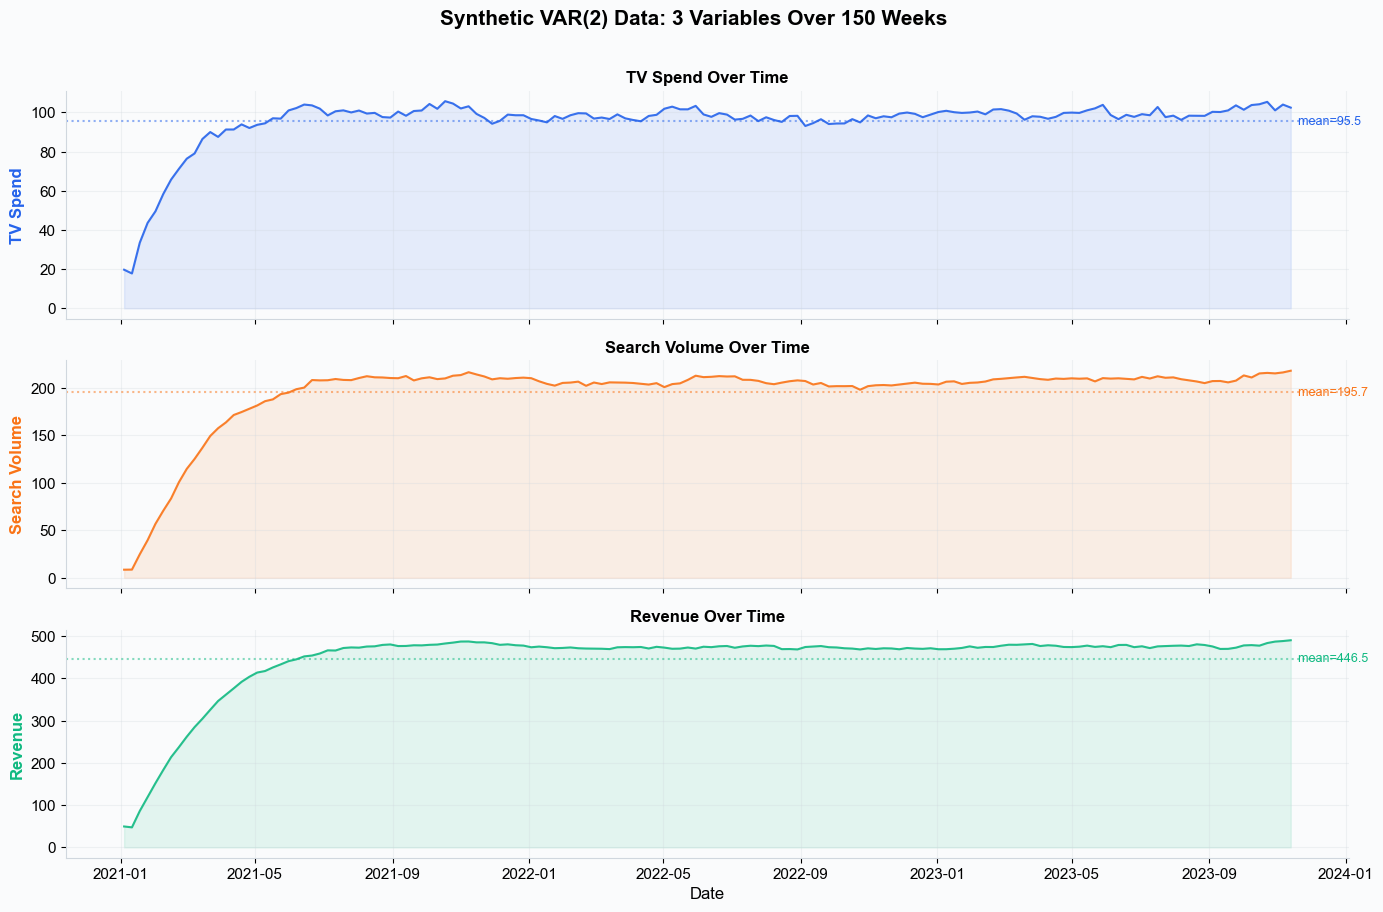

Notice how the series move together — this is the cross-channel effect we want to quantify.
Correlation matrix:
               TV Spend  Search Volume  Revenue
TV Spend          1.000          0.964    0.952
Search Volume     0.964          1.000    0.996
Revenue           0.952          0.996    1.000


In [5]:
# --- Visualize the synthetic time series ---

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for i, (var_name, color) in enumerate(zip(var_names, COLORS[:3])):
    ax = axes[i]
    ax.plot(df_var.index, df_var[var_name], color=color, linewidth=1.5, alpha=0.9)
    ax.fill_between(df_var.index, df_var[var_name], alpha=0.1, color=color)
    ax.set_ylabel(var_name, fontweight='bold', color=color)
    ax.set_title(f'{var_name} Over Time', fontsize=12)
    
    # Add mean line
    mean_val = df_var[var_name].mean()
    ax.axhline(y=mean_val, color=color, linestyle=':', alpha=0.5)
    ax.text(df_var.index[-1], mean_val, f'  mean={mean_val:.1f}', va='center', fontsize=9, color=color)

axes[-1].set_xlabel('Date')
plt.suptitle('Synthetic VAR(2) Data: 3 Variables Over 150 Weeks', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/03_var_synthetic_timeseries.png', dpi=180, bbox_inches='tight')
plt.show()

print('Notice how the series move together — this is the cross-channel effect we want to quantify.')
print(f'Correlation matrix:')
print(df_var.corr().round(3).to_string())

---

## Part 5: Building the Bayesian VAR in PyMC

Here's how you'd build this model in PyMC. We show the full model specification — this is the actual code structure Simba uses internally.

**Key components:**
1. **Minnesota prior** on coefficient matrices $\mathbf{A}_1, \mathbf{A}_2$
2. **LKJ Cholesky** prior on the innovation covariance $\boldsymbol{\Sigma}$
3. **Normal likelihood** for the observed data

In [6]:
# --- PyMC model specification (shown for reference, not executed) ---
# In production, you'd run pm.sample() here. We skip it and use simulated posteriors.

pymc_code = '''
import pymc as pm
import pytensor.tensor as pt

n_vars = 3       # TV Spend, Search Volume, Revenue
n_lags = 2       # VAR(2)
lambda_ = 0.2    # Minnesota shrinkage strength
own_lag_mu = 0.9  # Prior mean for own-lag coefficients

with pm.Model() as bayesian_var:
    
    # --- Minnesota prior on coefficient matrices ---
    A = []  # List of lag coefficient matrices
    for lag in range(1, n_lags + 1):
        A_lag = np.zeros((n_vars, n_vars))
        A_lag_list = []
        for i in range(n_vars):
            for j in range(n_vars):
                # Minnesota prior: own-lag centered at 0.9, cross-lag at 0.0
                if i == j:  # Own-lag
                    mu = own_lag_mu if lag == 1 else 0.0
                    sigma = lambda_ / lag
                else:  # Cross-lag
                    mu = 0.0
                    sigma = lambda_ / lag * (sigma_i / sigma_j)
                A_lag_list.append(
                    pm.Normal(f"A{lag}_{i}_{j}", mu=mu, sigma=sigma)
                )
        A.append(pt.stack(A_lag_list).reshape((n_vars, n_vars)))
    
    # --- Intercept ---
    c = pm.Normal("intercept", mu=0, sigma=10, shape=n_vars)
    
    # --- Innovation covariance (LKJ Cholesky) ---
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov",
        n=n_vars,
        eta=2.0,         # LKJ concentration (2.0 = mild shrinkage to identity)
        sd_dist=pm.HalfNormal.dist(sigma=5.0),
        compute_corr=True,
    )
    
    # --- Likelihood ---
    # For each time step t, compute the predicted mean
    mu_t = c + sum(A[lag] @ Y[t-lag-1] for lag in range(n_lags))
    
    obs = pm.MvNormal(
        "obs",
        mu=mu_t,
        chol=chol,
        observed=Y_obs,
    )
    
    # --- Sample ---
    # trace = pm.sample(2000, tune=1000, chains=4, target_accept=0.9)
'''

print('PyMC Bayesian VAR Model Specification')
print('=' * 50)
print(pymc_code)
print('\nNote: We do NOT run pm.sample() in this notebook (too slow).')
print('Instead, we simulate posterior draws to demonstrate the analysis outputs.')

PyMC Bayesian VAR Model Specification

import pymc as pm
import pytensor.tensor as pt

n_vars = 3       # TV Spend, Search Volume, Revenue
n_lags = 2       # VAR(2)
lambda_ = 0.2    # Minnesota shrinkage strength
own_lag_mu = 0.9  # Prior mean for own-lag coefficients

with pm.Model() as bayesian_var:

    # --- Minnesota prior on coefficient matrices ---
    A = []  # List of lag coefficient matrices
    for lag in range(1, n_lags + 1):
        A_lag = np.zeros((n_vars, n_vars))
        A_lag_list = []
        for i in range(n_vars):
            for j in range(n_vars):
                # Minnesota prior: own-lag centered at 0.9, cross-lag at 0.0
                if i == j:  # Own-lag
                    mu = own_lag_mu if lag == 1 else 0.0
                    sigma = lambda_ / lag
                else:  # Cross-lag
                    mu = 0.0
                    sigma = lambda_ / lag * (sigma_i / sigma_j)
                A_lag_list.append(
                    pm.Normal(f"A{lag}_{i}_{j}

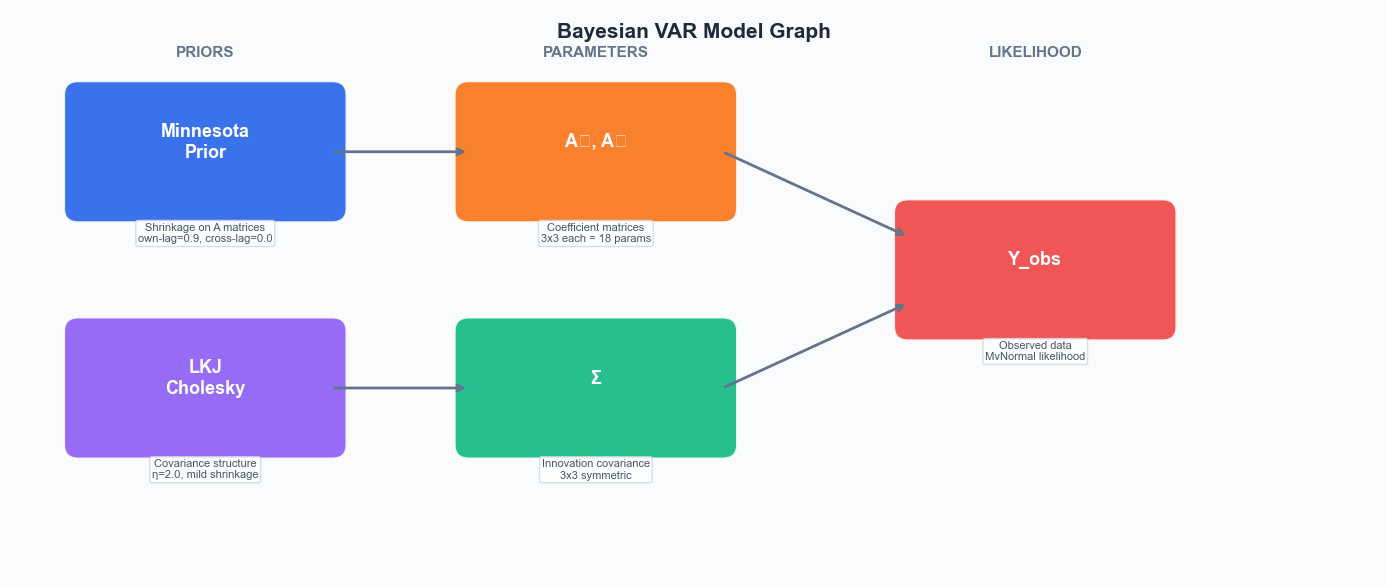

The model has three layers:
  PRIORS: Minnesota shrinkage + LKJ Cholesky on covariance
  PARAMETERS: Coefficient matrices A₁, A₂ and covariance Σ
  LIKELIHOOD: Multivariate Normal for observed Y


In [7]:
# --- Visualize the model structure ---

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#FAFBFC')

# Model components
components = {
    'Minnesota\nPrior': (2, 4.5, COLORS[0], 'Shrinkage on A matrices\nown-lag=0.9, cross-lag=0.0'),
    'LKJ\nCholesky': (2, 2.0, COLORS[4], 'Covariance structure\nη=2.0, mild shrinkage'),
    'A₁, A₂': (6, 4.5, COLORS[1], 'Coefficient matrices\n3x3 each = 18 params'),
    'Σ': (6, 2.0, COLORS[2], 'Innovation covariance\n3x3 symmetric'),
    'Y_obs': (10.5, 3.25, COLORS[3], 'Observed data\nMvNormal likelihood'),
}

for label, (x, y, color, desc) in components.items():
    # Main box
    w, h = 2.6, 1.2
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.15', facecolor=color,
                         edgecolor='white', linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, y + 0.1, label, ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')
    # Description below
    ax.text(x, y - 0.75, desc, ha='center', va='top', fontsize=8, color='#475569',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='#D0D7DE'))

# Arrows
arrow_pairs = [
    (2 + 1.3, 4.5, 6 - 1.3, 4.5),  # Minnesota -> A
    (2 + 1.3, 2.0, 6 - 1.3, 2.0),  # LKJ -> Sigma
    (6 + 1.3, 4.5, 10.5 - 1.3, 3.6),  # A -> Y
    (6 + 1.3, 2.0, 10.5 - 1.3, 2.9),  # Sigma -> Y
]
for x1, y1, x2, y2 in arrow_pairs:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#64748B', lw=2))

ax.text(7, 5.7, 'Bayesian VAR Model Graph', ha='center', fontsize=15, fontweight='bold', color='#1E293B')
ax.text(2, 5.5, 'PRIORS', ha='center', fontsize=11, fontweight='bold', color='#64748B')
ax.text(6, 5.5, 'PARAMETERS', ha='center', fontsize=11, fontweight='bold', color='#64748B')
ax.text(10.5, 5.5, 'LIKELIHOOD', ha='center', fontsize=11, fontweight='bold', color='#64748B')

plt.tight_layout()
plt.savefig('images/03_var_model_graph.png', dpi=180, bbox_inches='tight')
plt.show()

print('The model has three layers:')
print('  PRIORS: Minnesota shrinkage + LKJ Cholesky on covariance')
print('  PARAMETERS: Coefficient matrices A₁, A₂ and covariance Σ')
print('  LIKELIHOOD: Multivariate Normal for observed Y')

---

## Part 6: Simulating Posterior Draws

In a real analysis, `pm.sample()` would give us thousands of posterior draws for the coefficient matrices. Here, we simulate them by adding noise to the true coefficients. This lets us demonstrate IRF, FEVD, and long-run effects with realistic uncertainty bands.

In [8]:
# --- Simulate posterior draws ---

n_draws = 500  # Number of posterior samples

# Add noise to true coefficients to simulate posterior uncertainty
# More uncertainty for cross-lag coefficients (Minnesota prior is wider for own-lag)
posterior_A1 = np.zeros((n_draws, n_vars, n_vars))
posterior_A2 = np.zeros((n_draws, n_vars, n_vars))

for draw in range(n_draws):
    for i in range(n_vars):
        for j in range(n_vars):
            if i == j:  # Own-lag: less noise
                posterior_A1[draw, i, j] = A1_true[i, j] + np.random.normal(0, 0.05)
                posterior_A2[draw, i, j] = A2_true[i, j] + np.random.normal(0, 0.04)
            else:  # Cross-lag: more noise
                posterior_A1[draw, i, j] = A1_true[i, j] + np.random.normal(0, 0.08)
                posterior_A2[draw, i, j] = A2_true[i, j] + np.random.normal(0, 0.06)

print(f'Simulated {n_draws} posterior draws for A1 and A2.')
print(f'\nPosterior mean of A1 (should be close to true values):')
print(pd.DataFrame(posterior_A1.mean(axis=0), index=var_names,
                   columns=[f'{v} (t-1)' for v in var_names]).round(3).to_string())
print(f'\nTrue A1:')
print(pd.DataFrame(A1_true, index=var_names,
                   columns=[f'{v} (t-1)' for v in var_names]).round(3).to_string())

Simulated 500 posterior draws for A1 and A2.

Posterior mean of A1 (should be close to true values):
               TV Spend (t-1)  Search Volume (t-1)  Revenue (t-1)
TV Spend                0.699                0.003         -0.005
Search Volume           0.305                0.499          0.047
Revenue                 0.148                0.256          0.599

True A1:
               TV Spend (t-1)  Search Volume (t-1)  Revenue (t-1)
TV Spend                 0.70                 0.00           0.00
Search Volume            0.30                 0.50           0.05
Revenue                  0.15                 0.25           0.60


---

## Part 7: Impulse Response Functions (IRF) — The Key Output

The **Impulse Response Function** answers the most important marketing question:

> *"If I increase TV spend by 1 unit this week, what happens to Search and Revenue over the next 12 weeks?"*

### How IRF works:
1. Start with the system at equilibrium
2. Apply a one-time **shock** of 1 unit to one variable
3. Trace how the shock propagates through the system over time
4. The response at each horizon gives the **dynamic multiplier**

With Bayesian posterior draws, we get **uncertainty bands** around each IRF — showing how confident we are in the cross-channel effect.

In [9]:
def compute_irf(A1, A2, n_periods=12):
    """Compute impulse response function for a VAR(2) model.
    
    Returns Phi: shape (n_periods+1, n_vars, n_vars)
    Phi[h, i, j] = response of variable i at horizon h to a unit shock in variable j at time 0
    """
    n_vars = A1.shape[0]
    Phi = np.zeros((n_periods + 1, n_vars, n_vars))
    Phi[0] = np.eye(n_vars)  # Contemporaneous: identity (shock = 1 for own variable)
    
    for h in range(1, n_periods + 1):
        Phi[h] = A1 @ Phi[h - 1]
        if h >= 2:
            Phi[h] += A2 @ Phi[h - 2]
    
    return Phi

# Compute IRF for each posterior draw
n_periods = 12
irf_draws = np.zeros((n_draws, n_periods + 1, n_vars, n_vars))

for draw in range(n_draws):
    irf_draws[draw] = compute_irf(posterior_A1[draw], posterior_A2[draw], n_periods)

# Compute percentiles for uncertainty bands
irf_median = np.median(irf_draws, axis=0)
irf_lower = np.percentile(irf_draws, 3, axis=0)   # 3% (matches Simba's 94% HDI)
irf_upper = np.percentile(irf_draws, 97, axis=0)   # 97%
irf_q25 = np.percentile(irf_draws, 25, axis=0)
irf_q75 = np.percentile(irf_draws, 75, axis=0)

print(f'Computed IRF for {n_draws} posterior draws over {n_periods} periods.')
print(f'Each draw gives a {n_periods+1} x {n_vars} x {n_vars} response tensor.')

Computed IRF for 500 posterior draws over 12 periods.
Each draw gives a 13 x 3 x 3 response tensor.


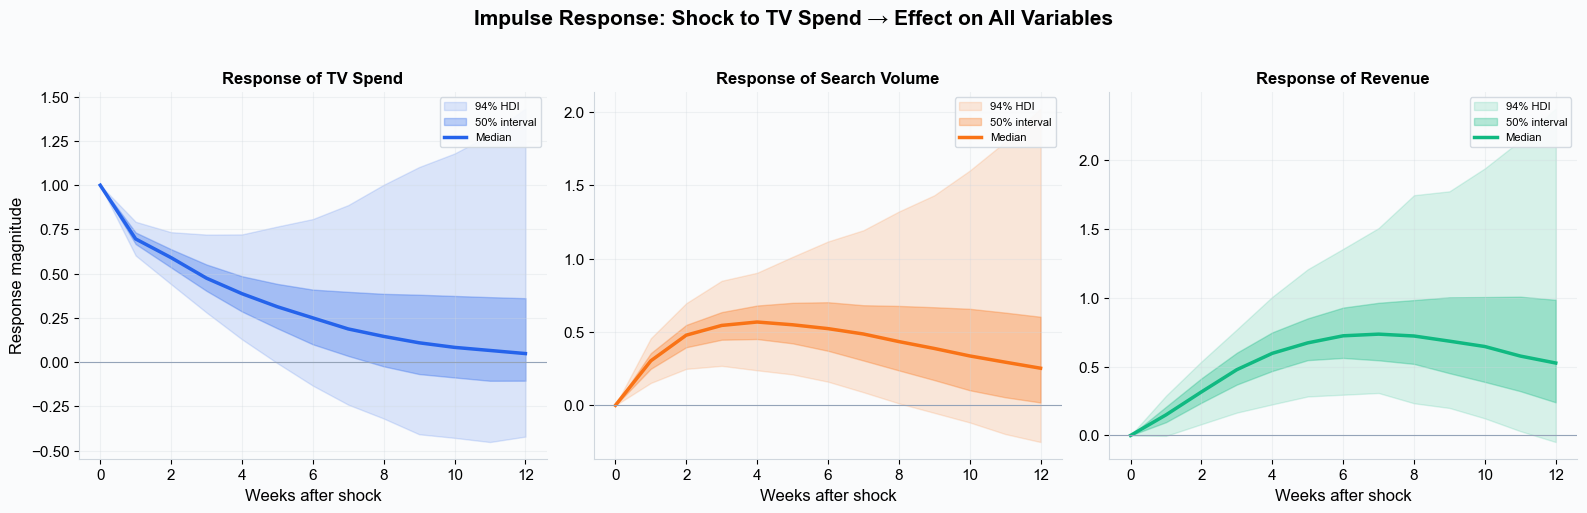

Reading the IRF:
  • TV Spend response: Starts at 1.0 (the shock), then decays as the effect fades
  • Search Volume: Peaks at week 1 (0.30) — TV ads drive search queries!
  • Revenue: Builds over first 2 weeks, then decays — both direct TV effect AND indirect via Search


In [10]:
# --- Plot IRF: Shock to TV Spend ---

shock_var = 0  # TV Spend
horizons = np.arange(n_periods + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (var_name, color) in enumerate(zip(var_names, COLORS[:3])):
    ax = axes[i]
    
    # 94% HDI band
    ax.fill_between(horizons, irf_lower[:, i, shock_var], irf_upper[:, i, shock_var],
                    alpha=0.15, color=color, label='94% HDI')
    # 50% band
    ax.fill_between(horizons, irf_q25[:, i, shock_var], irf_q75[:, i, shock_var],
                    alpha=0.3, color=color, label='50% interval')
    # Median
    ax.plot(horizons, irf_median[:, i, shock_var], color=color, linewidth=2.5, label='Median')
    
    ax.axhline(y=0, color='#94A3B8', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Weeks after shock')
    ax.set_title(f'Response of {var_name}', fontsize=12)
    ax.set_xticks(range(0, n_periods + 1, 2))
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel('Response magnitude')

plt.suptitle('Impulse Response: Shock to TV Spend → Effect on All Variables',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/03_irf_tv_shock.png', dpi=180, bbox_inches='tight')
plt.show()

print('Reading the IRF:')
print(f'  • TV Spend response: Starts at 1.0 (the shock), then decays as the effect fades')
print(f'  • Search Volume: Peaks at week 1 ({irf_median[1, 1, 0]:.2f}) — TV ads drive search queries!')
print(f'  • Revenue: Builds over first 2 weeks, then decays — both direct TV effect AND indirect via Search')

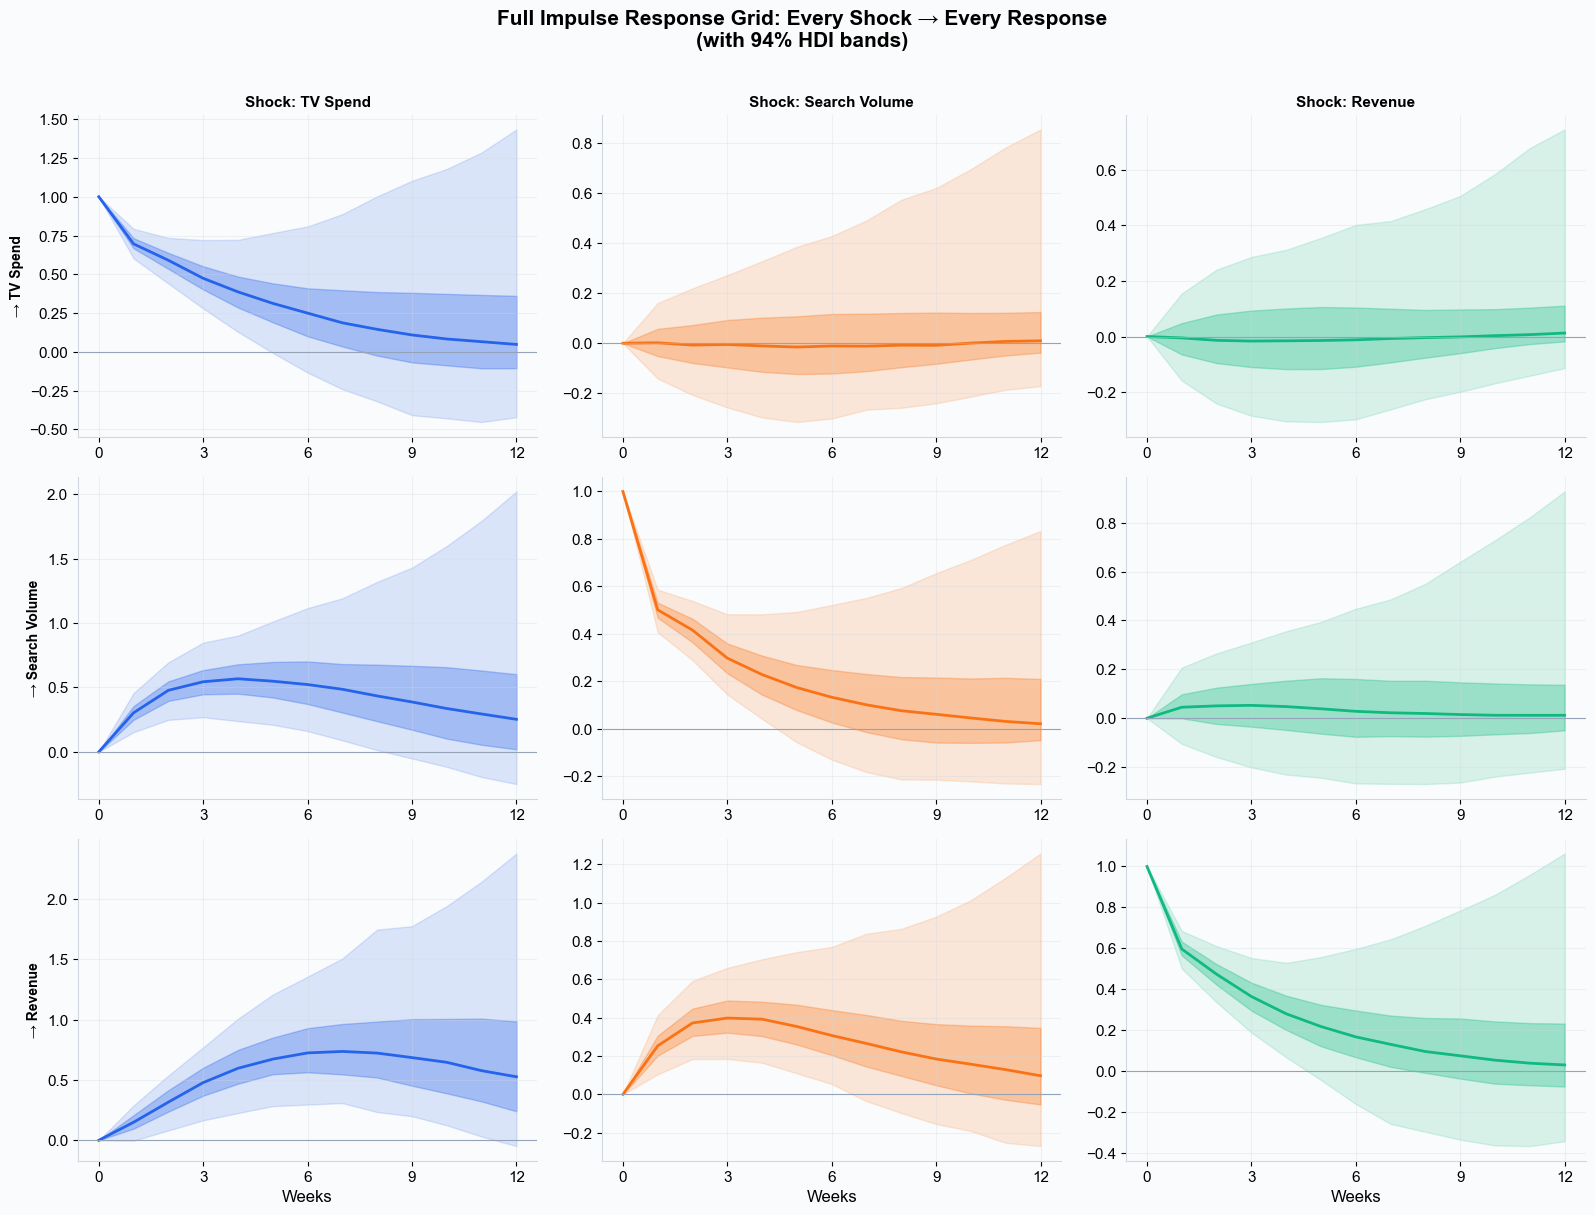

How to read this grid:
  Columns = which variable receives the shock
  Rows = which variable responds
  Diagonal = own response (always starts at 1.0)
  Off-diagonal = cross-channel effects (the interesting ones!)

Key findings:
  • TV → Search (row 2, col 1): Strong positive response, peaks at week 1
  • TV → Revenue (row 3, col 1): Positive but builds gradually (indirect via Search)
  • Search → Revenue (row 3, col 2): Strong immediate conversion effect
  • Revenue → TV/Search (col 3): Small feedback — more revenue doesn't cause more TV spend


In [11]:
# --- Full IRF Grid: All shocks x All responses ---

fig, axes = plt.subplots(n_vars, n_vars, figsize=(16, 12))

for shock_j in range(n_vars):
    for resp_i in range(n_vars):
        ax = axes[resp_i, shock_j]
        color = COLORS[shock_j]
        
        ax.fill_between(horizons, irf_lower[:, resp_i, shock_j], irf_upper[:, resp_i, shock_j],
                        alpha=0.15, color=color)
        ax.fill_between(horizons, irf_q25[:, resp_i, shock_j], irf_q75[:, resp_i, shock_j],
                        alpha=0.3, color=color)
        ax.plot(horizons, irf_median[:, resp_i, shock_j], color=color, linewidth=2)
        ax.axhline(y=0, color='#94A3B8', linestyle='-', linewidth=0.8)
        ax.set_xticks(range(0, n_periods + 1, 3))
        
        if resp_i == 0:
            ax.set_title(f'Shock: {var_names[shock_j]}', fontsize=11, fontweight='bold')
        if shock_j == 0:
            ax.set_ylabel(f'→ {var_names[resp_i]}', fontsize=10, fontweight='bold')
        if resp_i == n_vars - 1:
            ax.set_xlabel('Weeks')

plt.suptitle('Full Impulse Response Grid: Every Shock → Every Response\n(with 94% HDI bands)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/03_irf_full_grid.png', dpi=180, bbox_inches='tight')
plt.show()

print('How to read this grid:')
print('  Columns = which variable receives the shock')
print('  Rows = which variable responds')
print('  Diagonal = own response (always starts at 1.0)')
print('  Off-diagonal = cross-channel effects (the interesting ones!)')
print('\nKey findings:')
print('  • TV → Search (row 2, col 1): Strong positive response, peaks at week 1')
print('  • TV → Revenue (row 3, col 1): Positive but builds gradually (indirect via Search)')
print('  • Search → Revenue (row 3, col 2): Strong immediate conversion effect')
print('  • Revenue → TV/Search (col 3): Small feedback — more revenue doesn\'t cause more TV spend')

---

## Part 8: Forecast Error Variance Decomposition (FEVD)

While IRF shows the **direction and magnitude** of cross-channel effects, **FEVD** answers a different question:

> *"What fraction of Revenue's forecast uncertainty is explained by each variable?"*

If TV shocks explain 40% of Revenue's variance at the 12-week horizon, then TV is a **major driver** of Revenue even beyond its direct effect.

FEVD is computed by normalizing the squared IRF contributions.

In [12]:
def compute_fevd(irf_tensor):
    """Compute FEVD from IRF tensor.
    
    irf_tensor: shape (n_periods+1, n_vars, n_vars)
    Returns: shape (n_periods+1, n_vars, n_vars)
    fevd[h, i, j] = fraction of variable i's h-step forecast variance explained by shocks to variable j
    """
    n_periods_plus_1, n_vars, _ = irf_tensor.shape
    
    # Cumulative squared IRF responses
    cum_squared = np.zeros_like(irf_tensor)
    for h in range(n_periods_plus_1):
        cum_squared[h] = np.sum(irf_tensor[:h+1] ** 2, axis=0)
    
    # Normalize: each row sums to 1
    fevd = np.zeros_like(cum_squared)
    for h in range(n_periods_plus_1):
        for i in range(n_vars):
            total = cum_squared[h, i].sum()
            if total > 0:
                fevd[h, i] = cum_squared[h, i] / total
    
    return fevd

# Compute FEVD for each posterior draw
fevd_draws = np.zeros((n_draws, n_periods + 1, n_vars, n_vars))
for draw in range(n_draws):
    fevd_draws[draw] = compute_fevd(irf_draws[draw])

fevd_median = np.median(fevd_draws, axis=0)

print('FEVD at horizon 12 (median across posterior draws):')
print('(Rows = variable whose variance is being decomposed)')
print('(Columns = which shock explains that variance)\n')
print(pd.DataFrame(fevd_median[-1], index=var_names,
                   columns=[f'Due to {v}' for v in var_names]).round(3).to_string())

FEVD at horizon 12 (median across posterior draws):
(Rows = variable whose variance is being decomposed)
(Columns = which shock explains that variance)

               Due to TV Spend  Due to Search Volume  Due to Revenue
TV Spend                 0.907                 0.045           0.034
Search Volume            0.542                 0.398           0.033
Revenue                  0.550                 0.141           0.287


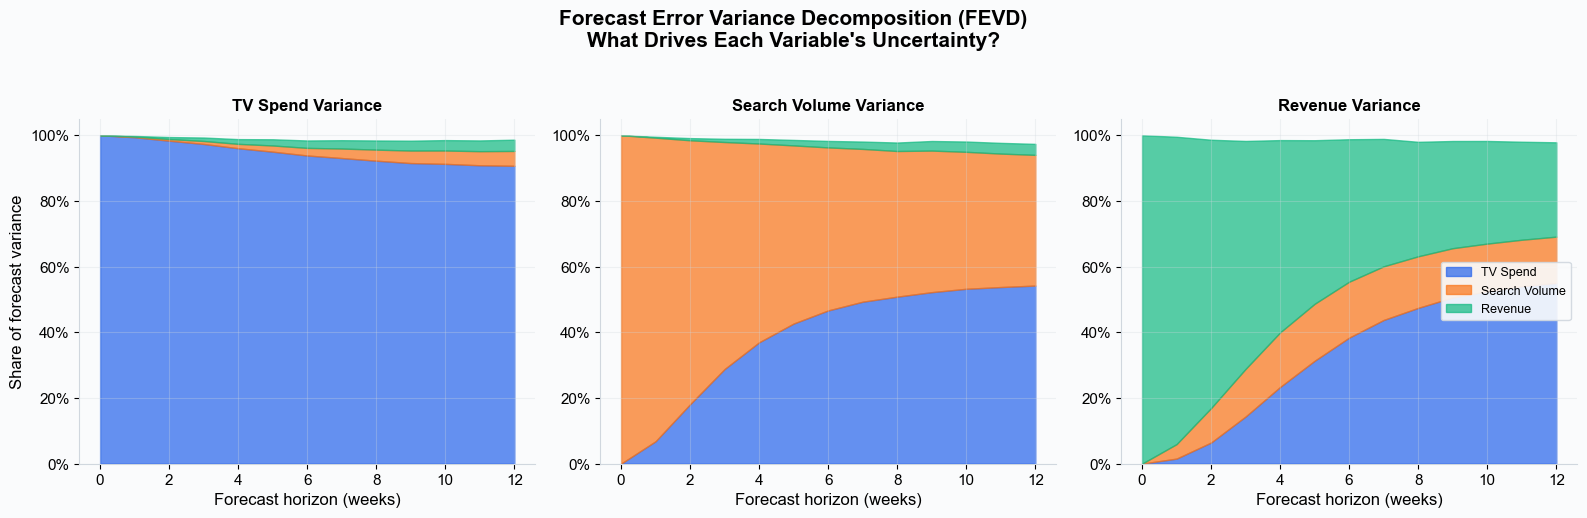

Interpretation:
  • TV Spend variance is almost entirely self-driven (it's an input we control)
  • Search Volume: ~54% of variance explained by TV at horizon 12!
  • Revenue: TV explains ~55%, Search explains ~14% of variance

This is the indirect TV effect that standard MMM misses.


In [13]:
# --- FEVD Stacked Area Charts ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (var_name, ax) in enumerate(zip(var_names, axes)):
    # Stack areas for each shock source
    bottoms = np.zeros(n_periods + 1)
    for j in range(n_vars):
        values = fevd_median[:, i, j]
        ax.fill_between(horizons, bottoms, bottoms + values,
                        alpha=0.7, color=COLORS[j], label=var_names[j])
        bottoms += values
    
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Forecast horizon (weeks)')
    ax.set_title(f'{var_name} Variance', fontsize=12)
    ax.set_xticks(range(0, n_periods + 1, 2))
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    if i == 0:
        ax.set_ylabel('Share of forecast variance')
    if i == 2:
        ax.legend(fontsize=9, loc='center right')

plt.suptitle('Forecast Error Variance Decomposition (FEVD)\nWhat Drives Each Variable\'s Uncertainty?',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('images/03_fevd_stacked.png', dpi=180, bbox_inches='tight')
plt.show()

print('Interpretation:')
print(f'  • TV Spend variance is almost entirely self-driven (it\'s an input we control)')
print(f'  • Search Volume: ~{fevd_median[-1, 1, 0]:.0%} of variance explained by TV at horizon 12!')
print(f'  • Revenue: TV explains ~{fevd_median[-1, 2, 0]:.0%}, Search explains ~{fevd_median[-1, 2, 1]:.0%} of variance')
print(f'\nThis is the indirect TV effect that standard MMM misses.')

---

## Part 9: Long-Run Multipliers

The **long-run multiplier matrix** $\boldsymbol{\Psi}_\infty$ gives the **total cumulative effect** of a permanent 1-unit increase in each variable.

$$\boldsymbol{\Psi}_\infty = (\mathbf{I} - \mathbf{A}_1 - \mathbf{A}_2 - \ldots)^{-1}$$

This is the most actionable output: "If I permanently increase TV spend by $1, what is the total long-run effect on Revenue (including all indirect pathways)?"

In [14]:
def compute_long_run_multiplier(A1, A2):
    """Compute Psi_inf = (I - A1 - A2)^{-1}.
    
    Returns None if the system is non-stationary (eigenvalues >= 1).
    """
    n_vars = A1.shape[0]
    A_sum = A1 + A2
    I = np.eye(n_vars)
    diff = I - A_sum
    
    # Check stationarity
    eigenvalues = np.abs(np.linalg.eigvals(A_sum))
    if np.any(eigenvalues >= 1.0):
        return None  # Non-stationary
    
    return np.linalg.inv(diff)

# Compute for each posterior draw
psi_draws = []
n_nonstationary = 0
for draw in range(n_draws):
    psi = compute_long_run_multiplier(posterior_A1[draw], posterior_A2[draw])
    if psi is not None:
        psi_draws.append(psi)
    else:
        n_nonstationary += 1

psi_draws = np.array(psi_draws)
psi_median = np.median(psi_draws, axis=0)
psi_lower = np.percentile(psi_draws, 3, axis=0)
psi_upper = np.percentile(psi_draws, 97, axis=0)

print(f'Computed long-run multipliers for {len(psi_draws)} stationary draws ')
print(f'({n_nonstationary} draws were non-stationary and excluded).\n')

print('Long-Run Multiplier Matrix (median):')
print('Psi[i,j] = total long-run effect on variable i from a permanent 1-unit increase in variable j\n')
print(pd.DataFrame(psi_median, index=var_names,
                   columns=[f'↑1 {v}' for v in var_names]).round(3).to_string())

Computed long-run multipliers for 382 stationary draws 
(118 draws were non-stationary and excluded).

Long-Run Multiplier Matrix (median):
Psi[i,j] = total long-run effect on variable i from a permanent 1-unit increase in variable j

               ↑1 TV Spend  ↑1 Search Volume  ↑1 Revenue
TV Spend             3.129            -0.672      -0.508
Search Volume        4.285             2.372      -0.258
Revenue              7.171             2.469       2.714


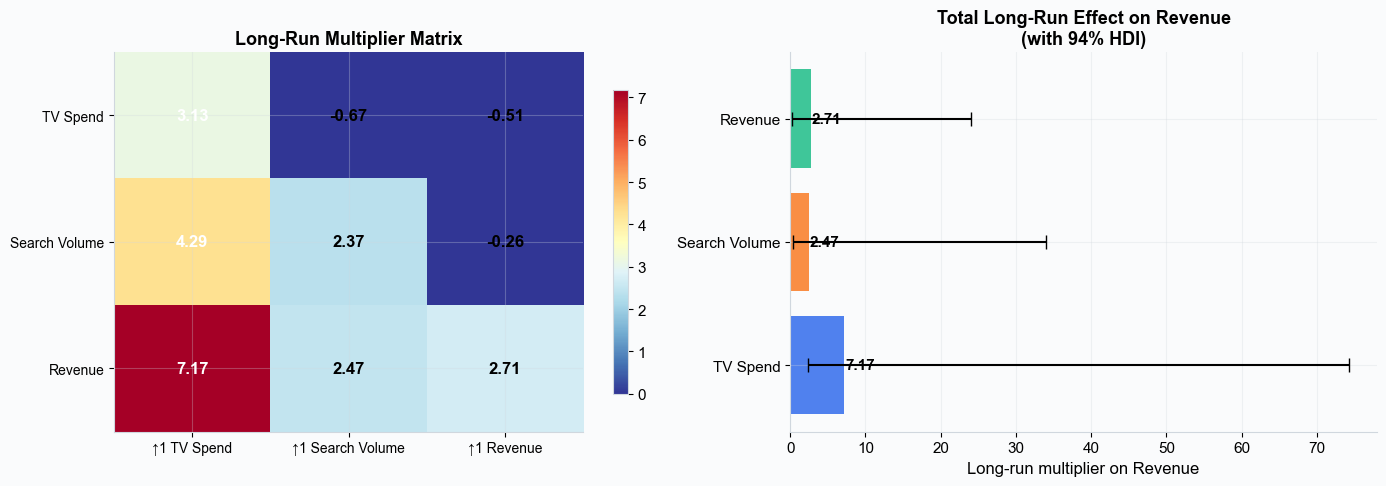

Key insight: The long-run effect of TV on Revenue is LARGER than the direct lag-1 coefficient.
  Direct effect (A1[Revenue, TV]): 0.15
  Long-run total effect: 7.17
  Ratio: 47.8x — the indirect pathway via Search adds significant value!


In [15]:
# --- Visualize long-run multipliers as heatmap + bar chart ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = ax1.imshow(psi_median, cmap='RdYlBu_r', aspect='auto', vmin=0)
ax1.set_xticks(range(n_vars))
ax1.set_yticks(range(n_vars))
ax1.set_xticklabels([f'↑1 {v}' for v in var_names], fontsize=10)
ax1.set_yticklabels(var_names, fontsize=10)
ax1.set_title('Long-Run Multiplier Matrix', fontsize=13)

# Add text annotations
for i in range(n_vars):
    for j in range(n_vars):
        val = psi_median[i, j]
        text_color = 'white' if val > 3 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=text_color)

plt.colorbar(im, ax=ax1, shrink=0.8)

# Bar chart: Revenue response to each variable
revenue_row = 2  # Revenue is the 3rd variable
bars = psi_median[revenue_row]
errs_low = bars - psi_lower[revenue_row]
errs_high = psi_upper[revenue_row] - bars

ax2.barh(range(n_vars), bars, color=COLORS[:n_vars], alpha=0.8,
         xerr=[errs_low, errs_high], capsize=5, error_kw={'linewidth': 1.5, 'color': '#475569'})
ax2.set_yticks(range(n_vars))
ax2.set_yticklabels(var_names)
ax2.set_xlabel('Long-run multiplier on Revenue')
ax2.set_title('Total Long-Run Effect on Revenue\n(with 94% HDI)', fontsize=13)

for i, v in enumerate(bars):
    ax2.text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('images/03_long_run_multipliers.png', dpi=180, bbox_inches='tight')
plt.show()

print('Key insight: The long-run effect of TV on Revenue is LARGER than the direct lag-1 coefficient.')
print(f'  Direct effect (A1[Revenue, TV]): {A1_true[2, 0]:.2f}')
print(f'  Long-run total effect: {psi_median[2, 0]:.2f}')
print(f'  Ratio: {psi_median[2, 0] / A1_true[2, 0]:.1f}x — the indirect pathway via Search adds significant value!')

---

## Part 10: Real Data Example

Let's apply the same analysis to our sample marketing dataset. We'll select 3 key variables and show what the VAR reveals about cross-channel dynamics.

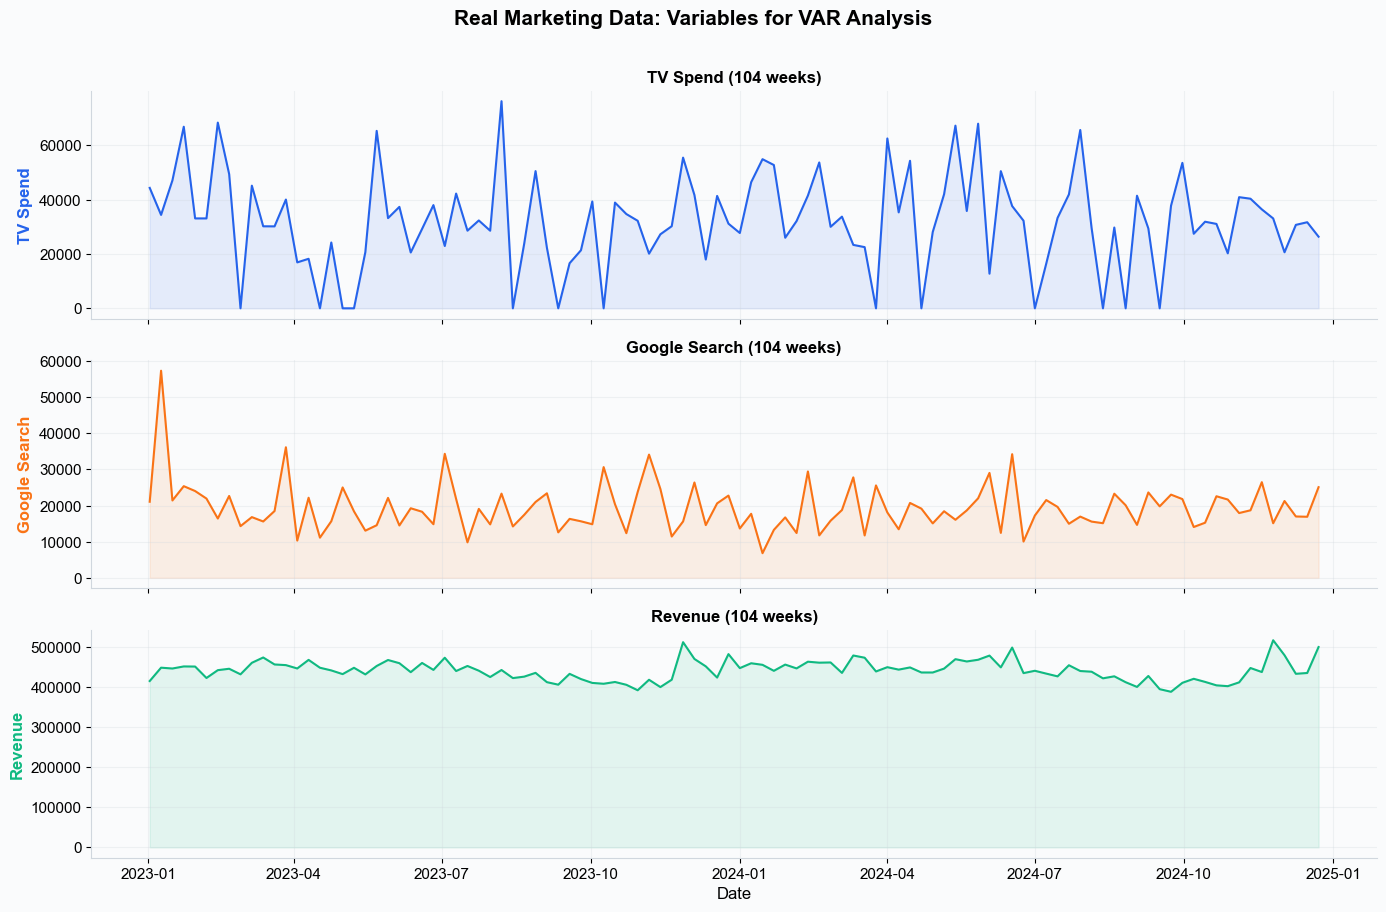

Data summary:
       tv_spend  google_search_spend   revenue
count     104.0                104.0     104.0
mean    31920.0              19363.0  441919.0
std     17695.0               6789.0   25075.0
min         0.0               6820.0  388468.0
25%     22450.0              14929.0  425014.0
50%     31973.0              18400.0  441482.0
75%     41430.0              22259.0  455957.0
max     76184.0              57286.0  517165.0

Correlation matrix:
                     tv_spend  google_search_spend  revenue
tv_spend                1.000               -0.017    0.224
google_search_spend    -0.017                1.000    0.076
revenue                 0.224                0.076    1.000

With 104 observations and 2 lags, we have 102 = 102 effective rows.
Minimum required: lags + 10 = 12 rows. We have 102, which is sufficient.


In [16]:
# --- Select and prepare real data for VAR ---

real_vars = ['tv_spend', 'google_search_spend', 'revenue']
real_labels = ['TV Spend', 'Google Search', 'Revenue']

df_real = df[['date'] + real_vars].copy()
df_real = df_real.set_index('date')

# Standardize for VAR (zero mean, unit variance)
means = df_real.mean()
stds = df_real.std()
df_std = (df_real - means) / stds

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for i, (col, label, color) in enumerate(zip(real_vars, real_labels, COLORS[:3])):
    ax = axes[i]
    ax.plot(df_real.index, df_real[col], color=color, linewidth=1.5)
    ax.fill_between(df_real.index, df_real[col], alpha=0.1, color=color)
    ax.set_ylabel(label, fontweight='bold', color=color)
    ax.set_title(f'{label} ({len(df_real)} weeks)', fontsize=12)

axes[-1].set_xlabel('Date')
plt.suptitle('Real Marketing Data: Variables for VAR Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/03_var_real_data.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Data summary:')
print(df_real.describe().round(0).to_string())
print(f'\nCorrelation matrix:')
print(df_real.corr().round(3).to_string())
print(f'\nWith {len(df_real)} observations and 2 lags, we have {len(df_real) - 2} = {len(df_real)-2} effective rows.')
print(f'Minimum required: lags + 10 = 12 rows. We have {len(df_real)-2}, which is sufficient.')

In [17]:
# --- Fit a simple OLS VAR to the real data and simulate Bayesian uncertainty ---
# (In production, you'd use PyMC sampling. Here we estimate via OLS and add posterior noise.)

Y_real = df_std.values
n_real = len(Y_real)
n_lags = 2
n_v = len(real_vars)

# Build lag matrix
X = np.ones((n_real - n_lags, 1 + n_v * n_lags))  # intercept + lagged values
Y_target = Y_real[n_lags:]

for lag in range(1, n_lags + 1):
    start_col = 1 + (lag - 1) * n_v
    X[:, start_col:start_col + n_v] = Y_real[n_lags - lag:n_real - lag]

# OLS estimate
beta_hat = np.linalg.lstsq(X, Y_target, rcond=None)[0]
residuals = Y_target - X @ beta_hat
sigma_hat = (residuals.T @ residuals) / (n_real - n_lags - beta_hat.shape[0])

# Extract A1, A2 from beta_hat
A1_hat = beta_hat[1:1+n_v].T
A2_hat = beta_hat[1+n_v:1+2*n_v].T

print('OLS Estimated A1 (lag 1 coefficients):')
print(pd.DataFrame(A1_hat, index=real_labels, columns=[f'{v} (t-1)' for v in real_labels]).round(3).to_string())
print('\nOLS Estimated A2 (lag 2 coefficients):')
print(pd.DataFrame(A2_hat, index=real_labels, columns=[f'{v} (t-2)' for v in real_labels]).round(3).to_string())

# Simulate posterior draws (adding Minnesota-style noise)
n_draws_real = 500
post_A1_real = np.zeros((n_draws_real, n_v, n_v))
post_A2_real = np.zeros((n_draws_real, n_v, n_v))

for draw in range(n_draws_real):
    for i in range(n_v):
        for j in range(n_v):
            noise_scale = 0.06 if i == j else 0.10
            post_A1_real[draw, i, j] = A1_hat[i, j] + np.random.normal(0, noise_scale)
            post_A2_real[draw, i, j] = A2_hat[i, j] + np.random.normal(0, noise_scale * 0.7)

OLS Estimated A1 (lag 1 coefficients):
               TV Spend (t-1)  Google Search (t-1)  Revenue (t-1)
TV Spend                0.020               -0.002          0.038
Google Search           0.110               -0.101         -0.143
Revenue                 0.162               -0.091          0.408

OLS Estimated A2 (lag 2 coefficients):
               TV Spend (t-2)  Google Search (t-2)  Revenue (t-2)
TV Spend               -0.003                0.141         -0.034
Google Search          -0.036               -0.032          0.046
Revenue                -0.097                0.042          0.195


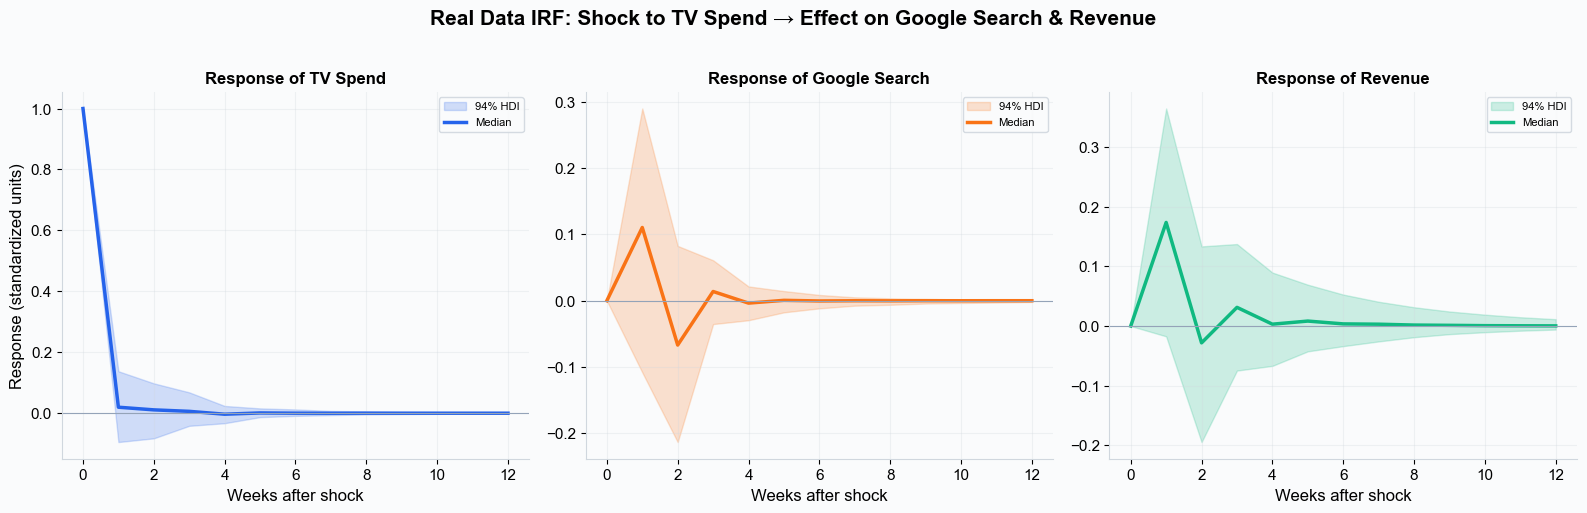

Real data results (standardized units):
  TV → Google Search at week 1: 0.111
  TV → Revenue at week 1: 0.173
  TV → Revenue cumulative (sum of 12 weeks): 0.199


In [18]:
# --- IRF for real data ---

irf_real = np.zeros((n_draws_real, n_periods + 1, n_v, n_v))
for draw in range(n_draws_real):
    irf_real[draw] = compute_irf(post_A1_real[draw], post_A2_real[draw], n_periods)

irf_real_med = np.median(irf_real, axis=0)
irf_real_lo = np.percentile(irf_real, 3, axis=0)
irf_real_hi = np.percentile(irf_real, 97, axis=0)

# Plot: Shock to TV -> Response of Google Search and Revenue
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (label, color) in enumerate(zip(real_labels, COLORS[:3])):
    ax = axes[i]
    ax.fill_between(horizons, irf_real_lo[:, i, 0], irf_real_hi[:, i, 0],
                    alpha=0.2, color=color, label='94% HDI')
    ax.plot(horizons, irf_real_med[:, i, 0], color=color, linewidth=2.5, label='Median')
    ax.axhline(y=0, color='#94A3B8', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Weeks after shock')
    ax.set_title(f'Response of {label}', fontsize=12)
    ax.set_xticks(range(0, n_periods + 1, 2))
    ax.legend(fontsize=8)

axes[0].set_ylabel('Response (standardized units)')
plt.suptitle('Real Data IRF: Shock to TV Spend → Effect on Google Search & Revenue',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/03_irf_real_data.png', dpi=180, bbox_inches='tight')
plt.show()

print('Real data results (standardized units):')
print(f'  TV → Google Search at week 1: {irf_real_med[1, 1, 0]:.3f}')
print(f'  TV → Revenue at week 1: {irf_real_med[1, 2, 0]:.3f}')
print(f'  TV → Revenue cumulative (sum of 12 weeks): {irf_real_med[:, 2, 0].sum():.3f}')

---

## Part 11: Practical Tips for Using VAR with MMM

### When to use VAR alongside MMM

| Scenario | Use MMM alone? | Add VAR? |
|---|---|---|
| Single brand, direct response only | Yes | Not needed |
| Brand + performance channels (TV + Search) | Yes | **Yes** — captures TV → Search pathway |
| Multi-brand portfolio | Yes | **Yes** — captures cross-brand halo effects |
| Long planning horizons (>6 months) | Useful but limited | **Yes** — long-run multipliers are essential |
| Attribution/contribution reporting only | Yes | Optional |

### How many lags?

| Data frequency | Typical lags | Minimum rows |
|---|---|---|
| Daily | 7–14 | lags + 10 |
| Weekly | 2–4 | lags + 10 |
| Monthly | 1–2 | lags + 10 |

In Simba, lag selection is **user-configured** — there is no automatic AIC/BIC selection. The minimum data requirement is `lags + 10` rows.

### Key parameters (Simba defaults)

| Parameter | Default | What it controls |
|---|---|---|
| $\lambda$ (shrinkage) | 0.2 | How tightly cross-lag coefficients are pulled toward 0 |
| Own-lag $\mu$ | 0.9 | Prior belief in persistence |
| LKJ $\eta$ | 2.0 | Mild shrinkage of correlations toward 0 |

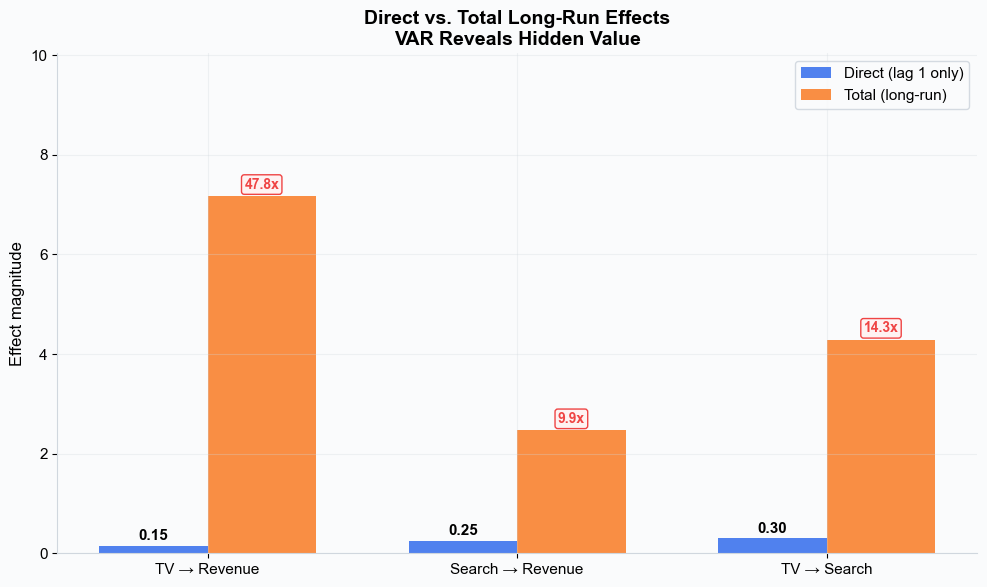

The total long-run effect is consistently larger than the direct effect.
This is the hidden value that VAR uncovers — and what standard MMM misses.

TV's total effect on Revenue is 47.8x its direct effect,
because TV also drives Search, which then drives Revenue.


In [19]:
# --- Summary visualization: Direct vs. Total effects ---

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['TV → Revenue', 'Search → Revenue', 'TV → Search']
direct_effects = [A1_true[2, 0], A1_true[2, 1], A1_true[1, 0]]
total_effects = [psi_median[2, 0], psi_median[2, 1], psi_median[1, 0]]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, direct_effects, width, label='Direct (lag 1 only)',
               color=COLORS[0], alpha=0.8)
bars2 = ax.bar(x + width/2, total_effects, width, label='Total (long-run)',
               color=COLORS[1], alpha=0.8)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Effect magnitude')
ax.set_title('Direct vs. Total Long-Run Effects\nVAR Reveals Hidden Value', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(total_effects) * 1.4)

# Add ratio annotations
for i in range(len(categories)):
    if direct_effects[i] > 0:
        ratio = total_effects[i] / direct_effects[i]
        ax.annotate(f'{ratio:.1f}x', xy=(i + width/2, total_effects[i] + 0.15),
                   fontsize=10, ha='center', color=COLORS[3], fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='#FEF2F2', edgecolor=COLORS[3]))

plt.tight_layout()
plt.savefig('images/03_direct_vs_total_effects.png', dpi=180, bbox_inches='tight')
plt.show()

print('The total long-run effect is consistently larger than the direct effect.')
print('This is the hidden value that VAR uncovers — and what standard MMM misses.')
print(f'\nTV\'s total effect on Revenue is {psi_median[2,0]/A1_true[2,0]:.1f}x its direct effect,')
print(f'because TV also drives Search, which then drives Revenue.')

---

## Summary

In this notebook, we built a **Bayesian VAR** model from scratch and demonstrated the three key outputs:

| Output | Question it answers | How to use it |
|---|---|---|
| **IRF** | "If I shock TV by 1 unit, what happens to Search and Revenue?" | Quantify cross-channel effects over time |
| **FEVD** | "What fraction of Revenue variance is driven by each channel?" | Identify the most important drivers |
| **Long-run multipliers** | "What is the total effect of TV on Revenue (all pathways)?" | Budget allocation that accounts for indirect value |

### Key takeaways:

1. **MMM captures direct effects; VAR captures indirect/lagged cross-channel pathways**
2. **The Minnesota prior** prevents overfitting by shrinking cross-lag coefficients toward zero
3. **Long-run multipliers are larger than direct effects** because they include indirect pathways (e.g., TV → Search → Revenue)
4. **Bayesian uncertainty** quantifies how confident we are in each cross-channel relationship

## Next Steps

**Notebooks:**
- [Notebook 13: MMM-to-VAR Pipeline](13-mmm-to-var-pipeline.ipynb) — How to link your MMM output to a VAR model for long-term analysis

**Core concepts:**
- [VAR Modeling](../docs/core-concepts/var-modeling.md) — Full theory behind Bayesian VAR with Minnesota priors
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md) — Why Bayesian approaches give better uncertainty quantification
- [Halo Effects](../docs/core-concepts/halo-effects.md) — Cross-brand effects that VAR can quantify

**Platform guide:**
- [Long-Term Effects](../docs/platform-guide/long-term-effects.md) — Using Simba's VAR module in production